In [ ]:
try:
    import pyLOM
    print('Entorno con pyLOM instalado')
except ImportError as e:
    print(e)
    print('Imported by local repository')
    import sys
    sys.path.append('/home/migueljaraiz/anaconda3/repos/pyLowOrder')

from FotR import FRODO
import matplotlib.pyplot as plt
import os

config = {
    'laptop': {
        'root_dir': '/home/migueljaraiz/anaconda3/repos/',
        'folder_to_save': '/home/migueljaraiz/anaconda3/repos/GMM_TIFON/',
    },
    'cluster': {
        'root_dir': '/home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_extended/outputs/',
        'folder_to_save': '/home/m.jaraiz/Documentos/GMM/GMM_TIFON/'
    }
}

pc = 'laptop'

db = FRODO(
    root_dir = config[pc]['root_dir'],
    format = 'PYLOM',
    file = 'CADGroup_3_completo_stage_1.h5')

db.extract_inputs(
    keys_inputs={
        'ptos': 'xyz',    # coordenadas del mallado → data_dict['inputs']['ptos']
        'aoa': 'aoa',   # variable paramétrica   → data_dict['inputs']['aoa']
        'mach': 'M',   # variable paramétrica   → data_dict['inputs']['M']
    },
    keys_aux={},
)

db.extract_outputs(
    keys_outputs={
        'cp': 'BoundaryValues_CoefPressure',
        'gradrho': 'AugStateGrad_DensityGradient_interp',  # field del Dataset → data_dict['outputs']['cp']
        'gradT': 'AugStateGrad_TemperatureGradient_interp'
        }
    
)

0 Warning! Import - NVTX not present!




[PYLOMReader] Dataset loaded in 1.211 s
Dataset of 9 variables:
  > CD  - max = 0.0853571747219292, min = 0.0211941016109823
  > CL  - max = 0.7128004506389523, min = 0.0017507663531984
  > CMy  - max = 0.0116312300308043, min = -0.0814396710024715
  > M  - max = 1.489529013633728, min = 0.3043437898159027
  > Re  - max = 2127846.6018327894, min = 315933.6875
  > aoa  - max = 4.983091831207275, min = 0.0221543479710817
  > varCD  - max = 0.0058622738263488, min = 1.5518123489720028e-18
  > varCL  - max = 0.0124718994142255, min = 5.734072955026623e-15
  > varCM  - max = 0.001136587303561, min = 1.5261117831895702e-16
and 29 fields with 13862 points:
  > AugStateGrad_DensityGradient_interp - max = 1625.1697879448745, min = -7090.855791525813, avg = -1.0555945956806825
  > AugStateGrad_EnergyStagnationDensityGradient_interp - max = 7441.320562346408, min = -28504.520387444205, avg = -1.8056840656202633
  > AugStateGrad_MomentumXGradient_interp - max = 28435.20276309105, min = -25007.89

In [2]:
# Acceder a los datos
xyz = db.sets.get_xyz()           # (npoints, 3)
aoa   = db.sets.get_variable('aoa') # (500,)
mach = db.sets.get_variable('mach')   # (500,)
cp  = db.sets.get_field('cp')     # (npoints, 500)
gradrho = db.sets.get_field('gradrho')[0, :, :]#np.linalg.norm(db.sets.get_field('gradrho'), ord=2,axis=0)
gradT = db.sets.get_field('gradT')[0, :, :]#np.linalg.norm(db.sets.get_field('gradT'), ord=2,axis=0)

from FotR import SAM
import torch
xyz_sort, order_sort = SAM.Weapons.sort_by_centroid(xyz)
cp_sort = cp[order_sort, :]
gradrho_sort = gradrho[order_sort, :]
gradT_sort = gradT[order_sort, :]

sep = 120
tensor_ptos = torch.from_numpy(xyz_sort[::sep, :])
tensor_cp   = torch.from_numpy(cp_sort[::sep,  :])
tensor_gradrho = torch.from_numpy(gradrho_sort[::sep, :])
tensor_gradT = torch.from_numpy(gradT_sort[::sep, :])

N = tensor_ptos.shape[0]

# ── derivada por longitud de arco ─────────────────────────────────────────
dcp_ds = torch.zeros(tensor_cp.shape, dtype=torch.float64)
for case in range(tensor_cp.shape[1]):
    dcp_ds[:, case] = SAM.Weapons.surface_derivative(
        X=tensor_ptos, f=tensor_cp[:, case], order=1
    )

def symlog(x, linthresh=1e-3):
    return torch.sign(x) * torch.log10(1 + torch.abs(x) / linthresh)

# Ejemplo
dcp_ds_log = symlog(dcp_ds, linthresh=1e-4)

db_one = db.copy()
db_one.sets.add_aux(
    array_name = 'dcp_ds',
    array = dcp_ds.numpy(),
    notes = 'Derivada sobre contorno')

db_one.sets.add_aux(
    array_name = 'log_dcp_ds',
    array = dcp_ds_log.numpy(),
    notes = 'Log derivada sobre contorno'
)

db_one.data_dict['inputs']['ptos'] = tensor_ptos.numpy()
db_one.data_dict['outputs']['cp'] = tensor_cp.numpy()
db_one.data_dict['outputs']['gradrho'] = tensor_gradrho.numpy()
db_one.data_dict['outputs']['gradT'] = tensor_gradT.numpy()
# display(db_one.df_data)

db_one.sets.create_jset(verbose=False)

features = ['log_dcp_ds', 'gradrho']
folder_name = '_'.join(features)
df_data_complete, _ = SAM.Weapons.GMM(
    df_data=db_one.df_data,
    BIC_study=True,
    groupby=["aoa", "mach"],
    nclusters=2,
    features=features,
    save_pictures=True,
    folder_to_save=os.path.join(config[pc]['folder_to_save'], f'{folder_name}/sep_{sep}'),
    n_components_range=range(1, 5),
    covariance_type="diag",
    max_iter=300,
    random_state=42,
    return_metrics_table=True,
    plot_global_analysis=True,
    verbose = True
)

os.makedirs(os.path.join(config[pc]['folder_to_save'], f'{folder_name}/sep_{sep}/isolate_cases'), exist_ok=True)
for case in range(len(df_data_complete['aoa'].unique())):
    df_case = df_data_complete.groupby(['aoa', 'mach']).get_group((df_data_complete['aoa'].unique()[case], df_data_complete['mach'].unique()[case]))
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    ax.scatter(df_case['x'], df_case['z'], c='black', s=1, edgecolor='k', alpha=0.7)
    ax.set_xlabel('x')
    ax.set_ylabel('z')
    ax.set_title(f'GMM Clustering (case {case}) - features: {features} - sep: {sep}')
    ax.set_ylim(df_case['z'].min() - 0.1, df_case['z'].max() + 0.1)
    
    ax1 = ax.twinx()
    ax1.scatter(df_case['x'], df_case['cp'], c=df_case['clusters_GMM'], s=50, edgecolor='k', alpha=0.7, cmap='viridis')
    ax1.set_ylabel('cp')
    
    plt.savefig(os.path.join(config[pc]['folder_to_save'], f'{folder_name}/sep_{sep}/isolate_cases', f'case_{case}.png'))
    plt.close()




 ---------- Starting GMM algorithm ---------- 

	Features: ['dcp_ds', 'gradrho']
	N Clusters: 2
	Files saved in /home/m.jaraiz/Documentos/GMM/GMM_TIFON/dcp_ds_gradrho/sep_20



GMM cases:   0%|          | 0/100 [00:00<?, ?case/s]

GMM clustering completed.


Text(0, 0.5, 'dcp_ds')

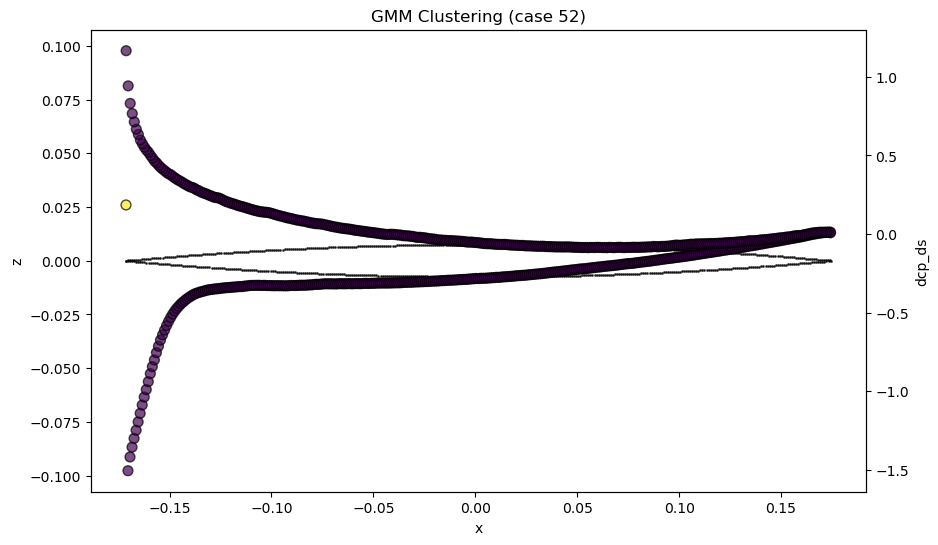

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
case = 52

x = df_data_complete.groupby(['aoa', 'mach']).get_group((df_data_complete['aoa'].unique()[case], df_data_complete['mach'].unique()[case]))['x']
z = df_data_complete.groupby(['aoa', 'mach']).get_group((df_data_complete['aoa'].unique()[case], df_data_complete['mach'].unique()[case]))['z']
cp = df_data_complete.groupby(['aoa', 'mach']).get_group((df_data_complete['aoa'].unique()[case], df_data_complete['mach'].unique()[case]))['cp']
clusters = df_data_complete.groupby(['aoa', 'mach']).get_group((df_data_complete['aoa'].unique()[case], df_data_complete['mach'].unique()[case]))['clusters_GMM']
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
# ax = ax.flatten()
sc = ax.scatter(
    x, z, c='black', s=1, edgecolor='k', alpha=0.7)
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_title(f'GMM Clustering (case {case})')
ax.set_ylim(z.min() - 0.1, z.max() + 0.1)
ax1 = ax.twinx()
sc1 = ax1.scatter(
    x, cp, c=clusters, s=50, edgecolor='k', alpha=0.7, cmap='viridis')
ax1.set_ylabel('dcp_ds')
# plt.colorbar(sc1, ax=ax1, label='dcp_ds')

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(
    df_data_complete['dcp_ds'],
    df_data_complete['gradrho'],
    c=df_data_complete['clusters_GMM'],
    cmap='viridis',
    label='All data')
ax.set_xlabel('dcp_ds')
ax.set_xscale('symlog')
ax.set_ylabel('gradrho')
ax.set_yscale('symlog')


import os
os.makedirs('/home/m.jaraiz/Documentos/GMM/GMM_TIFON/clusters_isolate/', exist_ok=True)
ngroups = len(df_data_complete.groupby(['aoa', 'mach']))

nrows = 3
ncols = ngroups // nrows + (ngroups % nrows > 0)
fig, ax = plt.subplots(nrows, ncols, figsize=(8*ncols, 6*nrows))
ax = ax.flatten()
for i, (aoa, mach) in enumerate(df_data_complete.groupby(['aoa', 'mach']).groups.keys()):
    group = df_data_complete[(df_data_complete['aoa'] == aoa) & (df_data_complete['mach'] == mach)]
    ax[i].scatter(
        group['x'],
        group['z'],
        c=group['clusters_GMM'],
        cmap='viridis',
        label=f'aoa={aoa}, M={mach}'
    )
    ax1 = ax[i].twinx()
    ax1.scatter(
        group['x'],
        group['cp'],
        c='red'
    )
    ax1.set_ylabel('cp', color='red')
    # for color, cluster in zip(['yellow', 'blue'], group['clusters_GMM'].unique()):
    #     cluster_group = group[group['clusters_GMM'] == cluster]
    #     ax[i].scatter(cluster_group['dcp_ds'], cluster_group['gradrho'], c=color)
    ax[i].set_xlabel('dcp_ds')
    ax[i].set_ylabel('gradrho')
    ax[i].set_title(f'aoa={aoa}, M={mach}')
    # ax[i].legend()
    # plt.savefig(f'/home/m.jaraiz/Documentos/GMM/GMM_TIFON/clusters_isolate/cluster_aoa_{aoa}_mach_{mach}.png')

# for key, group in df_data_complete.groupby(['aoa', 'mach']):
#     ax.scatter(group['dcp_ds'], group['gradrho'], label=f'aoa={key[0]}, M={key[1]}')
# ax.set_xlabel('dcp_ds')
# ax.set_ylabel('gradrho')
# ax.legend()
# plt.title(f'Scatter plot of dcp_ds vs gradrho (sep={sep})')
# plt.show()

#### Calculation of derivates in isolated case

In [ ]:
import matplotlib.pyplot as plt
import io
from PIL import Image


scale = 0.7
case_gif = 27

# ── Precomputar límites globales para ejes fijos ──────────────────────────────
# Se usan el subconjunto más denso (sep mínimo) como referencia
_ref_ptos = torch.from_numpy(xyz_sort[::20, :])
_ref_cp   = torch.from_numpy(cp_sort[::20, :])
_ref_dcp  = SAM.Weapons.surface_derivative(X=_ref_ptos, f=_ref_cp[:, case_gif], order=1)

Y_CP_MIN  = float(_ref_cp[:, case_gif].min())
Y_CP_MAX  = float(_ref_cp[:, case_gif].max())
Y_DCP_MIN = float(_ref_dcp.min())
Y_DCP_MAX = float(_ref_dcp.max())
X_MIN     = float(_ref_ptos[:, 0].min())
X_MAX     = float(_ref_ptos[:, 0].max())
Y_GEO_MIN = float(_ref_ptos.min()) * scale
Y_GEO_MAX = float(_ref_ptos.max()) * scale
# ─────────────────────────────────────────────────────────────────────────────

frames: list[Image.Image] = []

for sep in range(220, 20, -2):
    tensor_ptos = torch.from_numpy(xyz_sort[::sep, :])
    tensor_cp   = torch.from_numpy(cp_sort[::sep,  :])
    tensor_gradrho = torch.from_numpy(gradrho_sort[::sep, :])
    tensor_gradT = torch.from_numpy(gradT_sort[::sep, :])
    N = tensor_ptos.shape[0]

    # ── derivada por longitud de arco ─────────────────────────────────────────
    dcp_ds = torch.zeros(tensor_cp.shape, dtype=torch.float64)
    for case in range(tensor_cp.shape[1]):
        dcp_ds[:, case] = SAM.Weapons.surface_derivative(
            X=tensor_ptos, f=tensor_cp[:, case], order=1
        )
    # ─────────────────────────────────────────────────────────────────────────

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    fig.patch.set_facecolor('white')

    pl = ax.plot(
        tensor_ptos[:, 0],
        tensor_cp[:, case_gif],
        c = 'black',
        linewidth = 1,
    )
    ax.set_ylabel('y', fontsize=11)
    ax.set_xlabel('x', fontsize=11)
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_CP_MIN - 0.05 * abs(Y_CP_MIN), Y_CP_MAX + 0.05 * abs(Y_CP_MAX))
    ax.set_yticks([])

    # --- dcp/ds (eje derecho principal) --------------------------------------
    ax2 = ax.twinx()
    ax2.spines['right'].set_position(('outward', 0))   # superpuesto a ax1

    y  = tensor_gradrho[:, case_gif]
    n  = len(y)
    # mitad izquierda → rojo  |  mitad derecha → azul  (cara presión / succión)
    color = ['red', 'blue']

    sc2 = ax2.scatter(
        x=tensor_ptos[:n//2, 0],
        y=y[:n//2],
        c=[color[0]] * (n // 2),
        s=15,
        alpha=0.8,zorder=4,
    )
    
    sc3 = ax2.scatter(
        x=tensor_ptos[n - n // 2:, 0],
        y=y[n - n // 2:],
        c=[color[1]] * (n // 2),
        s=15,
        alpha=0.8,
        zorder=4,
    )
    ax2.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
    ax2.set_ylabel('grad_rho', fontsize=11)
    ax2.set_yscale('symlog')
    ax2.tick_params(axis='y', colors='crimson')
    ax2.set_ylim(Y_DCP_MIN * 1.1, Y_DCP_MAX * 1.1)
    # ax2.set_yscale('symlog', linthresh=1e-2)

    # --- título con info del frame -------------------------------------------
    ax.set_title(
        f'case {case_gif}  ·  sep = {sep}  ·  N = {N} pts',
        fontsize=12, pad=8
    )
    # Crear leyenda personalizada (linea negra: cp | puntos rojos/azules: dcp/ds). Crear linea negra y marcadores rojos y azules. Tres elementos: cp, dcp_ds_intrados, dcp_ds_extrados
    
    plt.legend(
        handles=[pl[0], sc2, sc3],
        labels=['cp', 'intrados', 'extrados'],
        loc='upper right',
        fontsize=10)
    # fig.legend(
    #     [pl, sc2],
    #     labels=['intrados', 'extrados'], loc='upper right', fontsize=10)
    plt.tight_layout()

    # ── capturar frame en memoria → PIL Image ─────────────────────────────────
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())   # .copy() libera el buffer
    plt.close(fig)
    buf.close()
    # ─────────────────────────────────────────────────────────────────────────

# ── Guardar GIF ───────────────────────────────────────────────────────────────
gif_name = f'tensor_gradrho_case{case_gif}_evolution.gif'
gif_path = config[pc]['folder_to_save']

import os
os.makedirs(gif_path, exist_ok=True)

frames[0].save(
    os.path.join(gif_path, gif_name),
    save_all=True,
    append_images=frames[1:],
    duration=200,          # ms por frame  → ajusta a tu gusto
    loop=0,                # 0 = bucle infinito
    optimize=False,
)

print(f'GIF guardado en: {gif_path}  ({len(frames)} frames)')

#### Calculation of clusters depending on the filter in airfoil